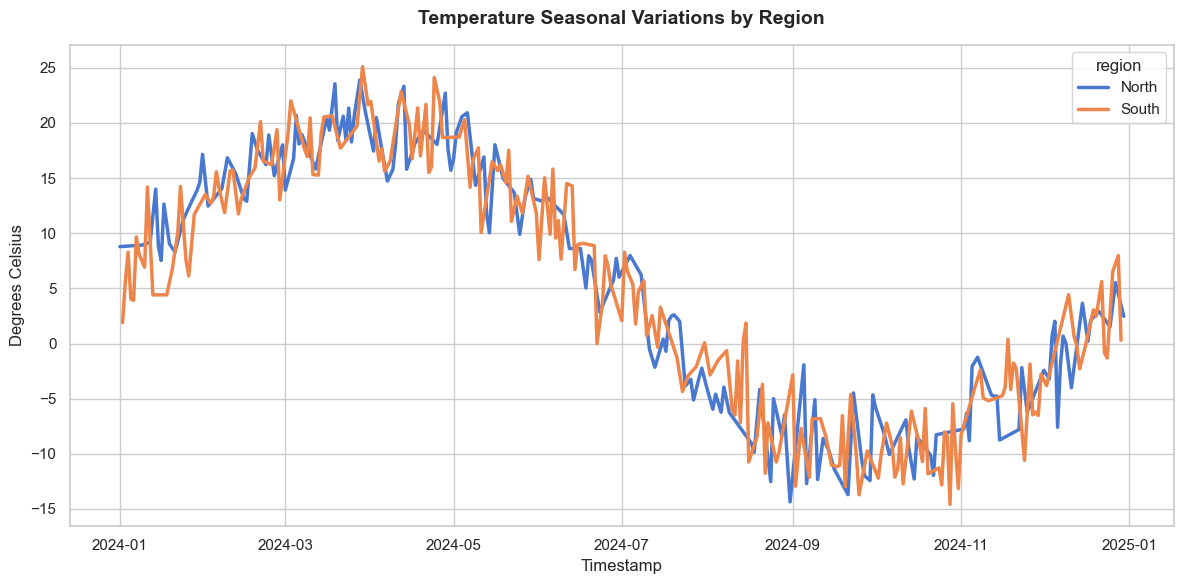

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt
from ts_data_generator import DataGen
from ts_data_generator.utils.functions import random_choice
from ts_data_generator.utils.trends import SinusoidalTrend

# Setup multi-variate generation
dg = DataGen(seed=42)
dg.start_datetime = "2024-01-01"
dg.end_datetime = "2024-12-30"
dg.to_granularity("D")

dg.add_dimension("region", random_choice(["North", "South"]))
dg.add_metric("temperature", {SinusoidalTrend(phase=10, amplitude=10, freq=1, noise_level=2), 
                              SinusoidalTrend(phase=20, amplitude=15, freq=365, noise_level=2)})

df = dg.data.reset_index() # Seaborn works best with long-format columns

# Styling parameters
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# Line plot grouped by region
sns.lineplot(
    data=df, 
    x="index", 
    y="temperature", 
    hue="region", 
    linewidth=2.5,
    palette="muted"
)

plt.title("Temperature Seasonal Variations by Region", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Timestamp", fontsize=12)
plt.ylabel("Degrees Celsius", fontsize=12)
plt.tight_layout()
plt.savefig("docs/assets/temperature_trends_by_region.png")
plt.show()


In [1]:
import plotly.express as px
import plotly.io as pio

pio.renderers.default = "browser"

from ts_data_generator import DataGen
from ts_data_generator.utils.trends import StockTrend

# Setup a stock price simulation
dg = DataGen(seed=777)
dg.start_datetime = "2024-01-01"
dg.end_datetime = "2024-01-07"
dg.to_granularity("5min")

dg.add_metric(
    "asset_price",
    {StockTrend(amplitude=150.0, noise_level=15), StockTrend(amplitude=200.0, noise_level=30)}
)

df = dg.data

# Render interactive Plotly line chart
fig = px.line(
    df,
    y="asset_price",
    title="Simulated Asset Price Walk (5-Min Granularity)",
    labels={
        "index": "Timestamp",
        "asset_price": "Price (USD)"
    },
    template="plotly_white"
)

# Customize layout
fig.update_xaxes(
    rangeslider_visible=True,
    showgrid=True
)

fig.update_yaxes(showgrid=True)

fig.update_traces(
    line_color="#0077CC",
    line_width=2
)

# Export interactive HTML
fig.write_html(
    "../docs/assets/simulated_asset_price_chart.html"
)
fig.show()



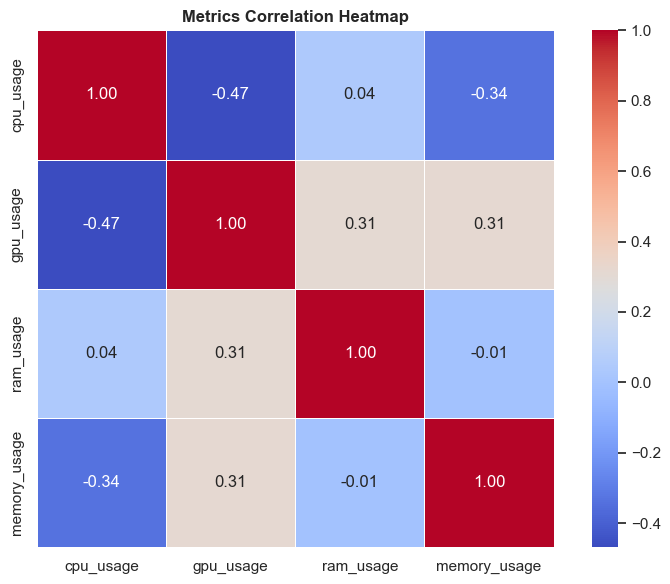

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

from ts_data_generator.utils.trends import LinearTrend
from ts_data_generator.utils.trends import SinusoidalTrend
from ts_data_generator.anomalies import PointAnomaly
from ts_data_generator.anomalies import MissingData

dg = DataGen()
dg.start_datetime = "2024-01-01"
dg.end_datetime = "2024-01-30"
dg.to_granularity("D")

# 2. Setup Base Trends (Baseline CPU)
cpu_trends = {
    LinearTrend(offset=30.0, slope=-15.0), # Creeping baseline load
    SinusoidalTrend(amplitude=10.0, freq=1.0, noise_level=2.0) # Daily cycles
}

gpu_trends = {
    LinearTrend(offset=20.0, slope=10.0), # Lower baseline load
    SinusoidalTrend(phase=0.5, amplitude=5.0, freq=2.0, noise_level=1.0) # Daily cycles
}

ram_trends = {
    LinearTrend(offset=50.0, slope=5.0), # Increasing baseline load
    SinusoidalTrend(phase=0.25, amplitude=15.0, freq=0.5, noise_level=3.0) # Longer cycles
}

memory_usage_trends = {
    LinearTrend(offset=40.0, slope=2.0), # Steady baseline
    SinusoidalTrend(phase=0.75, amplitude=20.0, freq=0.25, noise_level=4.0) # Very long cycles
}

# 3. Setup Anomalies to stack
spikes = PointAnomaly(probability=0.05, mode="additive", magnitude=(10.0, 15.0))
outages = MissingData(mode="burst", burst_probability=0.01, min_length=2, max_length=4)


# 4. Add Metric (providing both trends and the ordered anomalies list)
dg.add_metric(
    name="cpu_usage",
    trends=cpu_trends,
    anomalies=[spikes, outages]
)
dg.add_metric(
    name="gpu_usage",
    trends=gpu_trends,
    anomalies=[spikes, outages]
)
dg.add_metric(
    name="ram_usage",
    trends=ram_trends,
    anomalies=[spikes, outages]
)

dg.add_metric(
    name="memory_usage",
    trends=memory_usage_trends,
    anomalies=[spikes, outages]
)

df = dg.data.drop(columns=["epoch"]) # Drop dimension for correlation analysis

plt.figure(figsize=(8, 6))
sns.heatmap(
    df.corr(), 
    annot=True, 
    cmap="coolwarm", 
    fmt=".2f", 
    linewidths=.5,
    square=True
)
plt.title("Metrics Correlation Heatmap", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("docs/assets/correlation_heatmap.png", dpi=300)
plt.show()
